# Julia Scientific Programming
## Week 3 Peer Review Assignment: Fitting a parabola (curve) to given data.
## by Uki D. Lucas, August 19, 2020

For this assignment we provide **data that should be fitted a parabola**. 
You will be asked to **plot the data** and **adjust the coefficients of simple curve to give an approximate fit**. 
The purpose here is to use a Jupyter Notebook to **show all the step involved in an analysis**. 
The **exact fit is less important**; rather it should be clear that **each step can be reproduced** and the thinking followed.

In [1]:
using Plots
gr() # Activate the GR backend for use with Plots

Plots.GRBackend()

## Import the data
Import the supplied data representing 15 pairs to x- and y-values. 

In [2]:
using DelimitedFiles
data_tofit = DelimitedFiles.readdlm("Week3_PR_Data.dat", '\t') # read the tab-delimited text file

15×2 Array{Float64,2}:
 0.1268     -1.6417
 0.501309   -0.977698
 1.52801     0.527711
 1.70012     1.71152
 1.99249     1.891
 2.70608    -0.463428
 2.99493    -0.443567
 3.49185    -1.27518
 3.50119    -0.6905
 4.45992    -5.51613
 4.93697    -6.0017
 5.02329    -8.36417
 5.04234    -7.92448
 5.50739   -10.7748
 5.56867   -10.9172

## Extract x, y
Create the arrays x and y, assigning **x the first column** of data_tofit and **y the second column**

In [3]:
data_x = data_tofit[:,1] # all rows for the column 1
data_y = data_tofit[:,2] # all rows for the column 2

function plot_original()
    plot(data_x, data_y, 
        linetype = :scatter, 
        legend = false,
        aspect_ratio = 1
    )
end

plot_original (generic function with 1 method)

## Draw a scarrter plot with data
Then we do a **scatterplot**, this gives us the points the line must go through.

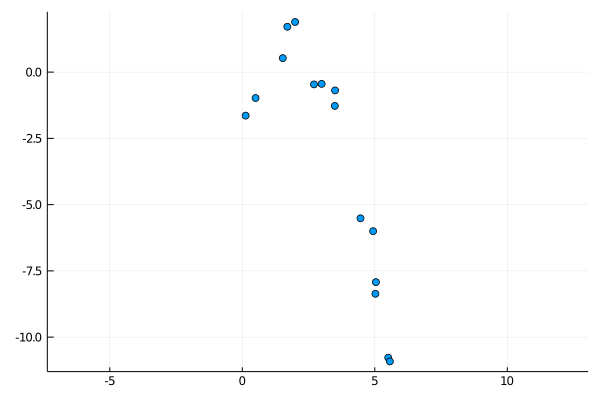

In [4]:
# Plot the x and y data points using a scatter plot of the x and y array variables
plot_original()

# Create a function

Create a function called parabfit, with x as the argument, returning a*x^2 + b*x + c

For the line, we need a function, which we now define. Note that the parameters a, b, c need not be passed to the function: we will keep resetting them to try to improve the fit.

In [5]:
function parabfit(x)
    # a: negative allows flipping vertically, if (a*x)^2 then if would be always positive
    # b: negative allows flipping horizontally
    # c: shifting the up and down
    return a*(x^2) + b*x + c
end

parabfit (generic function with 1 method)

Let's check that we do get a reasonable parabola. Choose your own interval [xmin, xmax] and parameters a, b, c. If it looks too much like a straight line, chance your choices until it does.

In [6]:
# Placeholders for y = f(x)

X = Array{Float64,1}(undef,length(-5:5)) # declare array of X with: undefined values,  11 values 
Y = Array{Float64,1}(undef,length(-5:5)) # declare array of Y with: undefined values,  11 values 

11-element Array{Float64,1}:
 2.3163789075e-314
 2.431957439e-314
 2.316378947e-314
 2.316378868e-314
 5.0e-324
 2.3163789866e-314
 2.316379026e-314
 2.316379105e-314
 1.5e-323
 1.5e-323
 1.0e-323

[2.3163783937e-314, 2.4319568224e-314, 2.316378433e-314, 2.3163783147e-314, 5.0e-324, 2.316378473e-314, 2.3163785123e-314, 2.316378552e-314, 1.5e-323, 1.5e-323, 1.0e-323]
[2.3163789075e-314, 2.431957439e-314, 2.316378947e-314, 2.316378868e-314, 5.0e-324, 2.3163789866e-314, 2.316379026e-314, 2.316379105e-314, 1.5e-323, 1.5e-323, 1.0e-323]


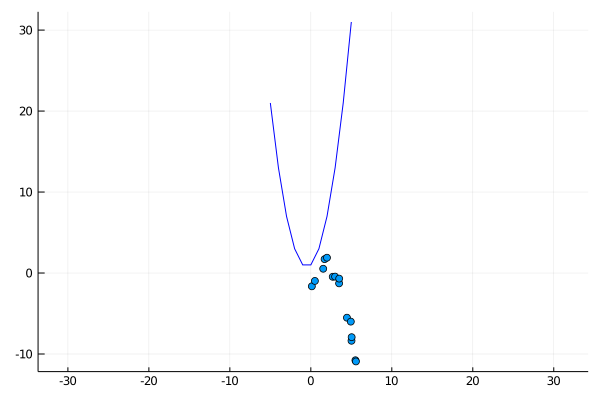

In [7]:
# Plot the function parabfit, for x values between -5 and 5

function plot_fit(a,b,c,color=:red)
    index = 1
    for x = -5:5
        X[index] = x
        Y[index] = parabfit(x)  # call our parabolic function
        index = index + 1
    end
    plot!(X,Y, linewidth = 1, linecolor="$color")
    
end

println(X) # show created arrays
println(Y) # show created arrays

plot_original()
a,c,b = 1,1,1 # Create variables a, b and c, assigning each the value 1
plot_fit(a,b,c,:blue)

# Hyperparameters improvements

Now we choose a, b, c and plot the curve together with the points. 

$ y = a*x^2 + b*x + c$

Note that by looking at where the data points lie, we can deduce some of the properties for a, b, c, as follows.

- The plot must have a **y-intersection that is close to 0, so c is close to 0**. 
- Also, the **parabola is open downwards, so a must be negative**. 
- Finally, it has its **maximum at a positive x, so b must be positive**. 

Use plot() to start with the scatter plot and plot!() to add the curve for parabfit. (There are other ways to do this ...)

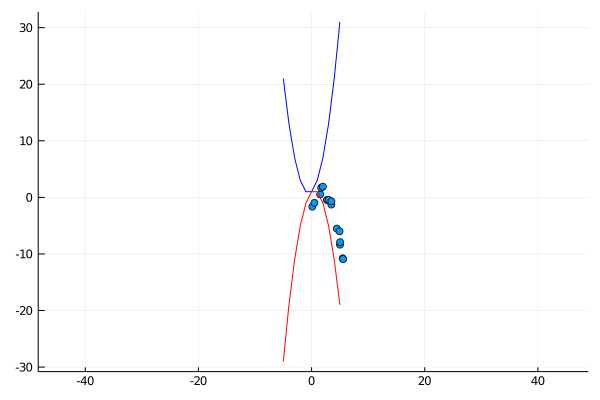

In [8]:
plot_original()

a =  1       
b =  1        
c =  1       
plot_fit(a,b,c, blue)

a = -1       # negative to flip the parabolla veritically
b =  1        
c =  1       
plot_fit(a,b,c, red)

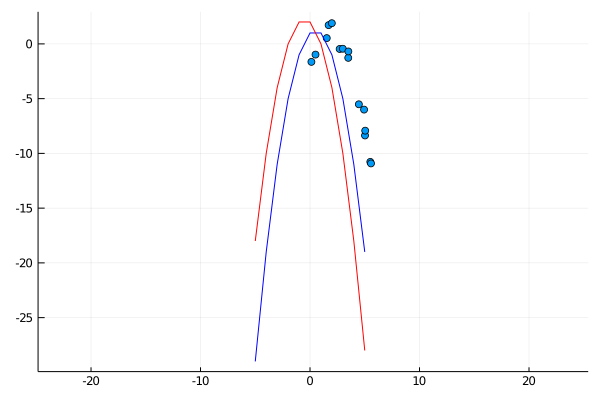

In [9]:
plot_original()

a = -1       # negative to flip the parabolla veritically
b =  1        
c =  1       
plot_fit(a,b,c, blue)

a =  -1      # negative to flip the parabolla veritically
b =  -1      # negative to flip horizontally
c =  2       # move up
plot_fit(a,b,c, red)

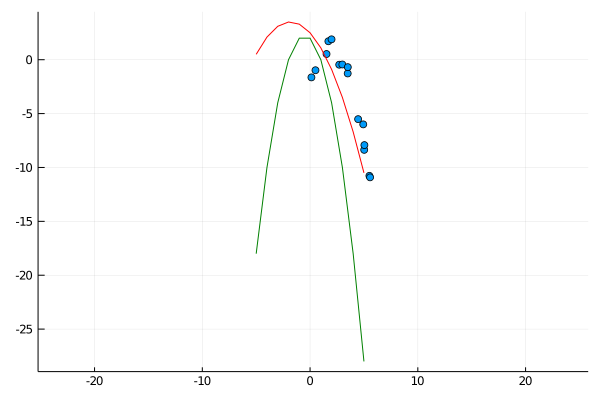

In [10]:
plot_original()

a =  -1      # negative to flip the parabolla veritically
b =  -1      # negative to flip horizontally
c =  2       # move up to 2
plot_fit(a,b,c, green)

a = -0.3     # negative to flip the parabolla veritically, adjust the "curvature" for the parabola, bigger is deeper -0.35
b = -1.1   # negative to flip horizontally, -1.2
c =  2.5      # move up to 2
plot_fit(a,b,c, red)

## Unfortunately the suggested values:
- a = -0.8
- b = 3
- c = -2

## are WAY OFF...

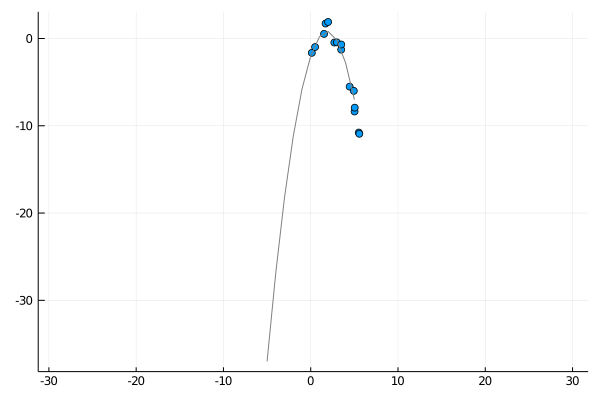

In [39]:
plot_original()

a = -0.8 # suggested in class
b = 3    # suggested in class
c = -2   # suggested in class
plot_fit(a,b,c, :gray)


# The best fit, by simply guessing numbers

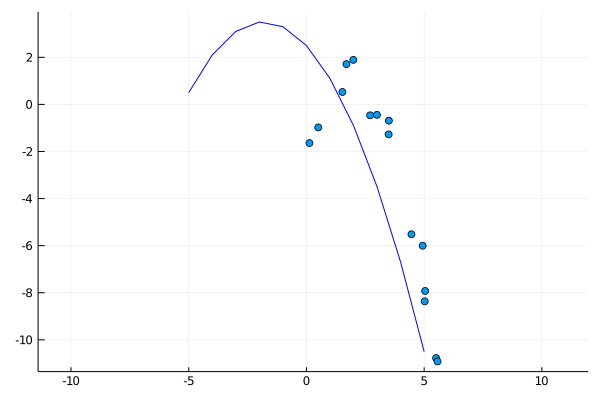

In [41]:
plot_original()

a = -0.3     # negative to flip the parabolla veritically, adjust the "curvature" for the parabola, opening and closing
b = -1.1     # negative to flip horizontally
c =  2.5     # move up and down
plot_fit(a,b,c, :blue)


# Computationally, figure appoximate value of c

In [29]:
data_y # 15-element Array{Float64,1}:
println("minimum of y ", minimum(data_y))
println("maximum of y ", maximum(data_y))

println("minimum of x ", minimum(data_x))
println("maximum of x ", maximum(data_x))


y_max = maximum(data_y)
#find(a->a==y_max, data_y)
index_y_max = findall(data_y .== maximum(data_y))
println("the aproximate value of c = y_max is at the index of ", index_y_max, " value is ", data_y[index_y_max] )

x_for_y_max = data_x[index_y_max]
println("x_for_y_max ", x_for_y_max)


minimum of y -10.917187797703853
maximum of y 1.8910000148140624
minimum of x 0.1268004831284406
maximum of x 5.568665171088307
the aproximate value of c = y_max is at the index of [5] value is [1.8910000148140624]
x_for_y_max [1.9924936253216172]


# Computationally, figure approximate value of a

In [27]:
for index = 1:length(data_x)
    x = data_x[index]
    y = data_y[index]
    h = 2.5 # x_vertex, approximate
    c = maximum(data_y)
    
    #y = a(x-h)^2 + c  # solve equation for a
    #y - c = a(x-h)^2
    #(y - c)/((x-h)^2) = a
    a = (y - c)/((x-h)^2)
    
    println("a = ", a)
end

a = -0.6272456969881547
a = -0.7181142935467779
a = -1.4429994287816135
a = -0.28051564701973447
a = 0.0
a = -55.44102970436409
a = -9.530492262959632
a = -3.218407466800492
a = -2.575357730550293
a = -1.9282854754360454
a = -1.329005807379411
a = -1.6106773090615982
a = -1.5186063236737104
a = -1.4004032617047322
a = -1.3601558660393445


a = -0.986
c = 2.0910000148140626


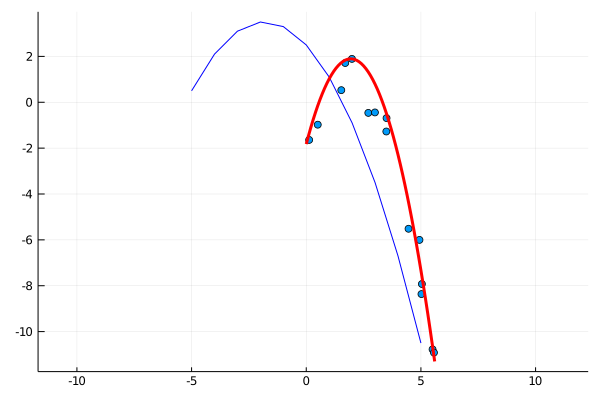

In [31]:
# y_max is at the index of [5] value is [1.8910000148140624]
# x_for_y_max [1.9924936253216172]

function plot_solution(a,b,c,color=:red)
    steps = 5.6
    X = Array{Float64,1}(undef,57) # declare array of X with: undefined values  
    Y = Array{Float64,1}(undef,57) # declare array of Y with: undefined values 
    
    h = 1.9924936 # x, where f(x) = 1.891, or maximum(data_y)
    index = 1
    for x = 0:0.1:steps
        X[index] = x
        Y[index] = a*(x-h)^2 + b*x + c
        index = index + 1
    end
    plot!(X,Y, linewidth = 3, linecolor="$color") #, linetype = :scatter
end
    

plot_original()

a = -0.3     # negative to flip the parabolla veritically, adjust the "curvature" for the parabola, bigger is deeper -0.35
b = -1.1     # negative to flip horizontally, -1.2
c =  2.5     # move up to 2
plot_fit(a,b,c, :blue)


a = -0.386 - 0.6
println("a = ", a)
b = -0.1
c = maximum(data_y) + 0.2     # set programatically, 1.891
println("c = ", c)
plot_solution(a,b,c, :red)


# Final Solution

### Original equation

$ y = a*x^2 + b*x + c$

### Imporved equation

$ y = a*(x-h)^2 + b*x + c$

where:

- a = -0.986 
- c = 2.0910000148140626 # y = maximum(data_y)
- h = 1.9924936 # x, where f(x) = 1.891, or maximum(data_y)



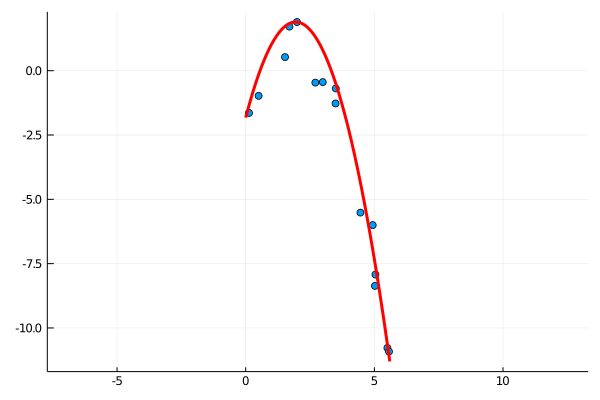

In [42]:
plot_original()

a = -0.986
b = -0.1
c = 2.0910000148140626

# and extra parameter I have added:
h = 1.9924936 # x, where f(x) = 1.891, or maximum(data_y)

plot_solution(a,b,c, :red)